In [ ]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ==================================================
# 1. Set paths and analysis year range
# ==================================================
input_folder = r"C:\Users\*****\Desktop\Results\Extreme_Climate_Extraction"
output_file = r"C:\Users\*****\Desktop\Results\Figure4\Sen_MK_results.csv"

# Set the start and end years for analysis here (inclusive)
# Set both to None if you wish to analyze all years
ANALYSIS_START_YEAR = 1980
ANALYSIS_END_YEAR   = 2020

# ==================================================
# 2. Sen's slope and MK test functions
# ==================================================
def sen_slope(years, values):
    """Calculate Sen's slope (units/year)"""
    n = len(years)
    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            if years[j] != years[i]:
                slopes.append((values[j] - values[i]) / (years[j] - years[i]))
    return np.median(slopes) if slopes else np.nan


def mk_test(values, alpha=0.1):
    """Mann‑Kendall trend test (with tie correction)"""
    n = len(values)
    s = 0
    for k in range(n - 1):
        for j in range(k + 1, n):
            s += np.sign(values[j] - values[k])
    unique_vals, counts = np.unique(values, return_counts=True)
    var_s = n * (n - 1) * (2 * n + 5) / 18.0
    for c in counts:
        if c > 1:
            var_s -= c * (c - 1) * (2 * c + 5) / 18.0
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    p = 2 * (1 - stats.norm.cdf(np.abs(z)))
    if p <= alpha:
        trend = "increasing" if s > 0 else "decreasing"
    else:
        trend = "no trend"
    return z, p, trend


# ==================================================
# 3. Iterate over all CSV files
# ==================================================
all_results = []
csv_files = [f for f in os.listdir(input_folder) if f.endswith("_extracted.csv")]

for file in csv_files:
    filepath = os.path.join(input_folder, file)
    indicator = file.split("_")[0]          # Extract indicator name from filename

    df = pd.read_csv(filepath, encoding="utf-8")

    # Identify all year columns (column names convertible to integer and greater than 1900)
    year_cols = []
    for col in df.columns:
        try:
            year = int(col)
            if year > 1900:
                year_cols.append(col)
        except:
            continue

    # Filter by the specified start and end years
    if ANALYSIS_START_YEAR is not None or ANALYSIS_END_YEAR is not None:
        filtered = []
        for col in year_cols:
            y = int(col)
            if (ANALYSIS_START_YEAR is None or y >= ANALYSIS_START_YEAR) and \
               (ANALYSIS_END_YEAR is None or y <= ANALYSIS_END_YEAR):
                filtered.append(col)
        year_cols = filtered

    # Sort by year value
    year_cols_sorted = sorted(year_cols, key=lambda x: int(x))
    years = np.array([int(y) for y in year_cols_sorted])

    if len(years) == 0:
        continue   # No data for this indicator within the specified year range

    # Analyze each site (each row)
    for idx, row in df.iterrows():
        # Extract metadata columns (string, leave empty if missing)
        meta = {
            "NUM": row.get("NUM", row.get("NUM", "")),
            "ID": row.get("ID", row.get("ID", "")),
            "Name": row.get("Name", row.get("Name", "")),
            "Cite": row.get("Cite", row.get("Cite", "")),
            "Lon": row.get("Lon", row.get("Lon", "")),
            "Lat": row.get("Lat", row.get("Lat", "")),
            "Type1": row.get("Type1", row.get("Type1", "")),
            "Type2": row.get("Type2", row.get("Type2", "")),
            "Type": row.get("Type", row.get("Type", ""))
        }

        # Extract the site's values for the selected years
        vals = []
        for y in year_cols_sorted:
            try:
                v = float(row[y])
                vals.append(v if not np.isnan(v) else np.nan)
            except:
                vals.append(np.nan)
        vals = np.array(vals)

        # Remove missing values
        valid_mask = ~np.isnan(vals)
        valid_years = years[valid_mask]
        valid_vals = vals[valid_mask]

        if len(valid_vals) < 4:
            continue

        # Calculate Sen's slope and MK test
        slope = sen_slope(valid_years, valid_vals)
        z, p, trend = mk_test(valid_vals)

        # Combine results
        result = {"Indicator": indicator}
        result.update(meta)
        result.update({
            "Start_Year": valid_years[0],
            "End_Year": valid_years[-1],
            "Sen_slope": slope,
            "Z_value": z,
            "P_value": p,
            "Trend": trend
        })
        all_results.append(result)

# ==================================================
# 4. Save results
# ==================================================
results_df = pd.DataFrame(all_results)

# Adjust column order, placing metadata columns first
desired_order = [
    "Indicator", "NUM", "ID", "Name", "Cite", "Lon", "Lat",
    "Type1", "Type2", "Type",
    "Start_Year", "End_Year", "Sen_slope", "Z_value", "P_value", "Trend"
]
# Keep only columns that actually exist
existing_order = [col for col in desired_order if col in results_df.columns]
results_df = results_df[existing_order]

results_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Analysis complete! Processed {len(all_results)} site-indicator records.")
print(f"Specified analysis year range: {ANALYSIS_START_YEAR} — {ANALYSIS_END_YEAR}")
print(f"Results saved to: {output_file}")

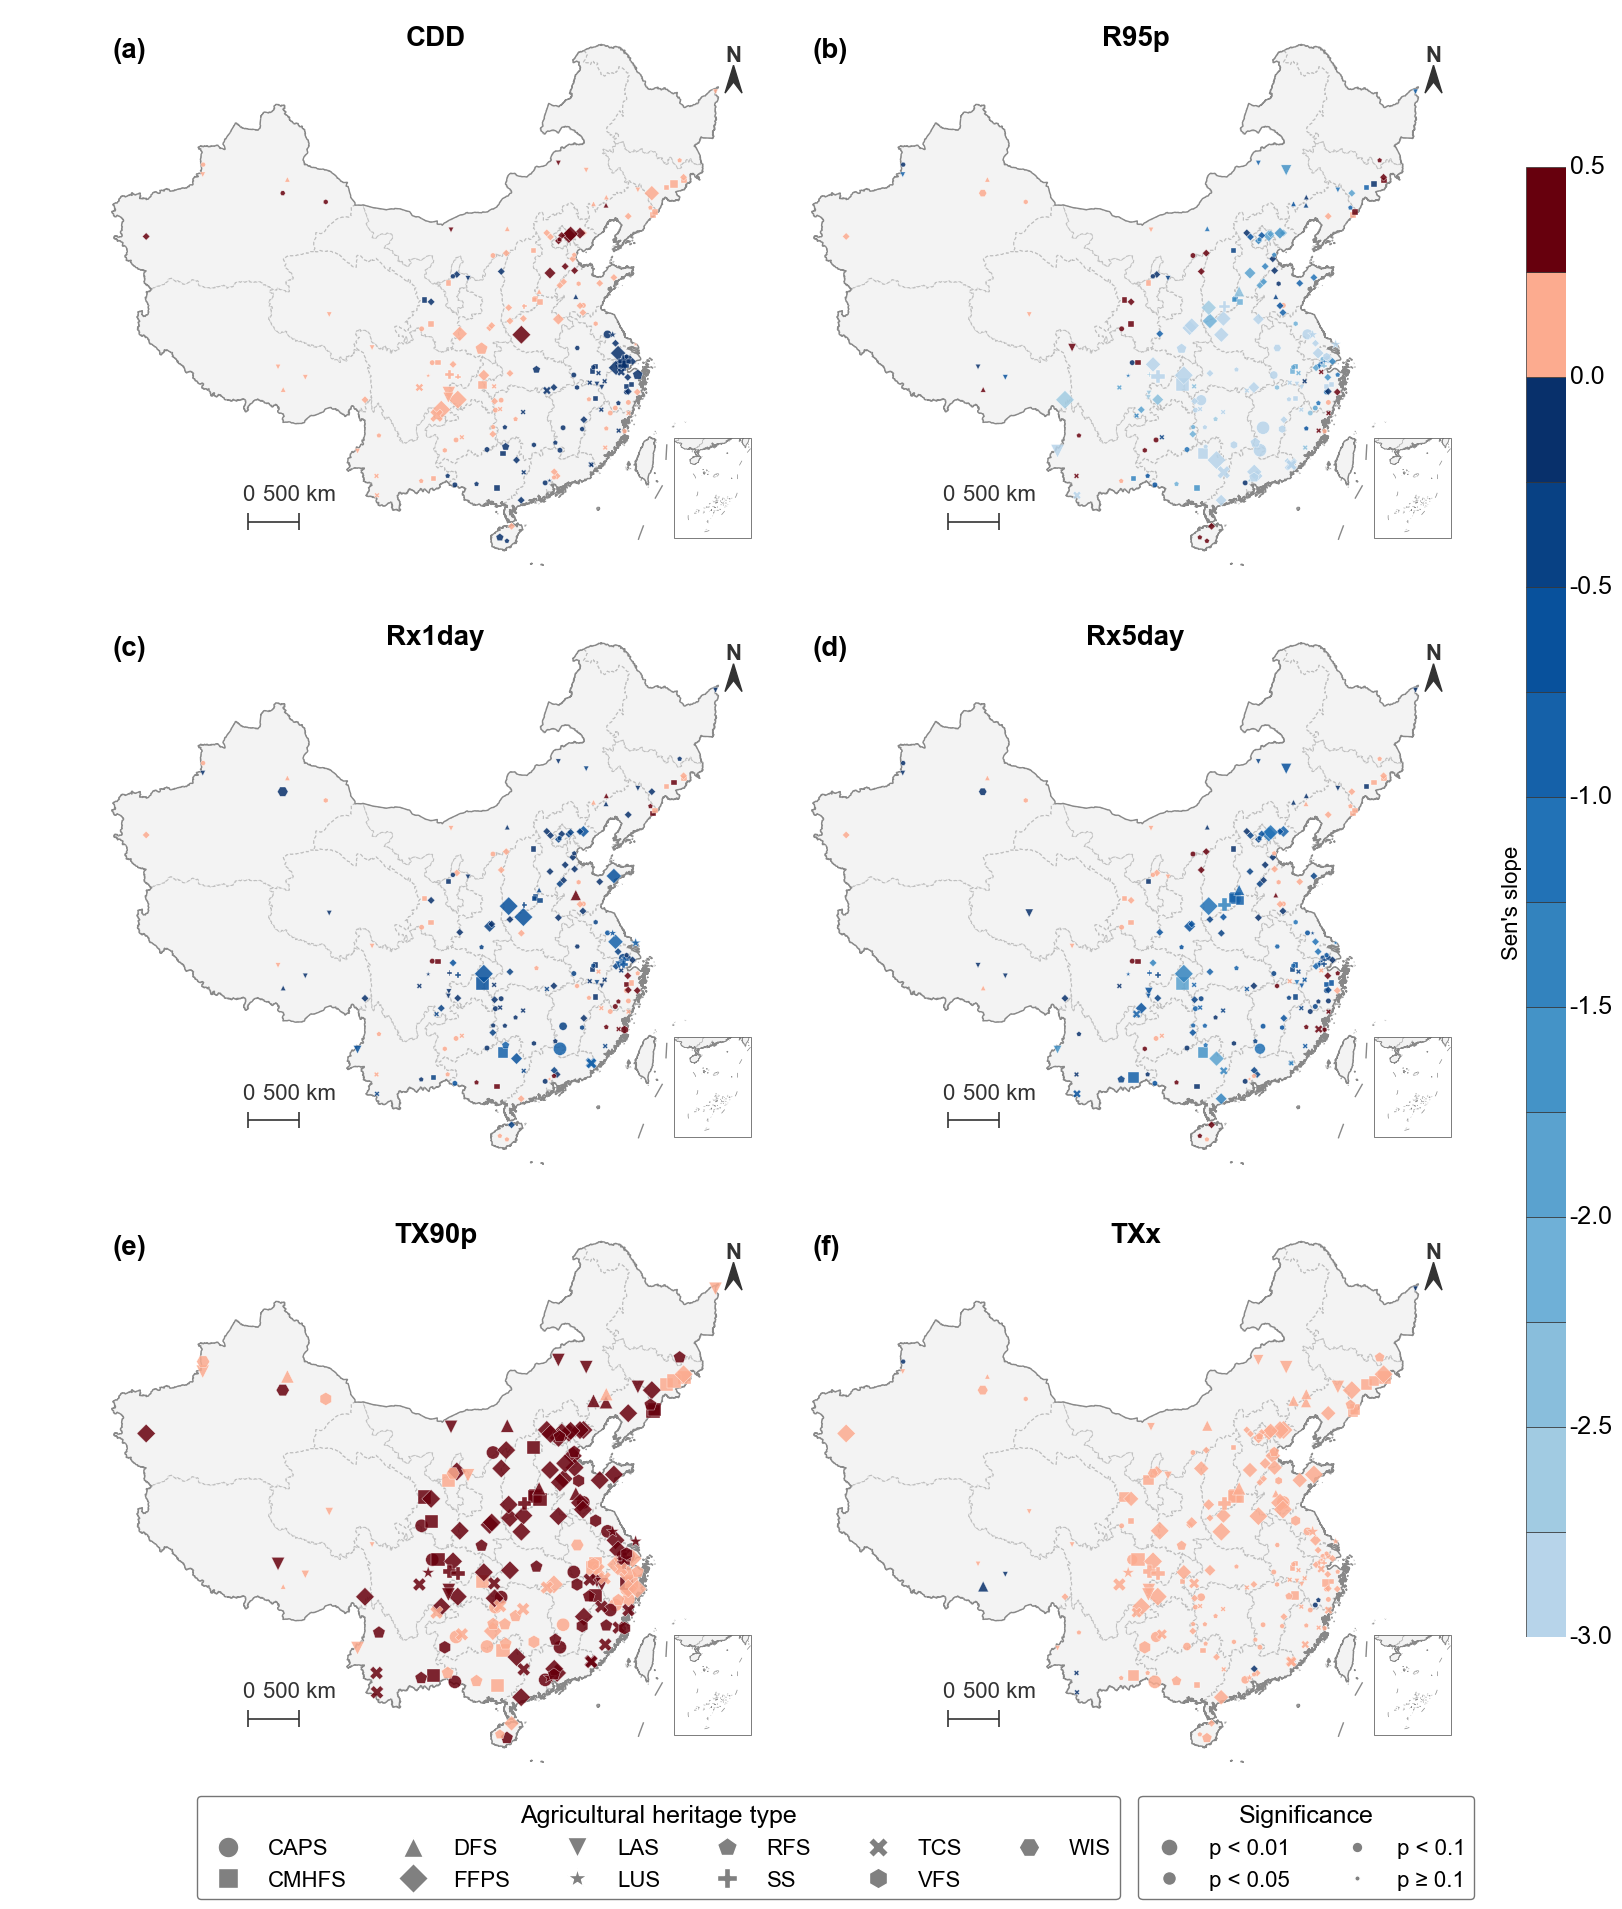

✅ 组图已保存至：C:\Users\28550\Desktop\Results\Figure4\Extreme_Climate_Trends_Map.png
✅ 手动裁剪完成（左1200 上900 右1500 下200）


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import pymannkendall as mk
from shapely.geometry import Point
import glob
import os
import warnings
from PIL import Image
warnings.filterwarnings('ignore')

# ==================== Paths and Parameters ====================
START_YEAR = 1980
END_YEAR   = 2020
data_dir   = r"C:\Users\*****\Desktop\Results\Extreme_Climate_Extraction"
shp_folder = r"C:\Users\*****\Desktop\Results\GS(2020)4619"
output_png = r"C:\Users\*****\Desktop\Results\Figure4\Extreme_Climate_Trends_Map.png"

indicator_files = [
    "CDD_1980_2025_extracted.csv",
    "R95p_1980_2025_extracted.csv",
    "RX1day_1980_2025_extracted.csv",
    "RX5day_1980_2025_extracted.csv",
    "TX90p_1980_2025_extracted.csv",
    "TXx_1980_2025_extracted.csv"
]
indicator_names = ["CDD", "R95p", "Rx1day", "Rx5day", "TX90p", "TXx"]
letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# ==================== Color grading ====================
bounds = np.arange(-3.0, 0.5 + 0.25, 0.25)   # 15 boundaries = 14 intervals
neg_colors = [plt.cm.Blues(0.3 + 0.7 * (i / 11)) for i in range(12)]  # -3.0~0
pos_colors = [plt.cm.Reds(0.3 + 0.7 * (i / 1)) for i in range(2)]     # 0~0.5
all_colors = neg_colors + pos_colors

cmap = mcolors.ListedColormap(all_colors)
norm = mcolors.BoundaryNorm(bounds, len(all_colors), clip=True)

# ==================== Custom functions ====================
def add_north(ax, labelsize=13, loc_x=0.92, loc_y=0.92, width=0.02, height=0.05, pad=0.08):
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()
    ylen = maxy - miny
    xlen = maxx - minx
    left  = [minx + xlen*(loc_x - width/2), miny + ylen*(loc_y - pad)]
    right = [minx + xlen*(loc_x + width/2), miny + ylen*(loc_y - pad)]
    top   = [minx + xlen*loc_x, miny + ylen*(loc_y - pad + height)]
    center= [minx + xlen*loc_x, left[1] + (top[1]-left[1])*0.4]
    triangle = mpatches.Polygon([left, top, right, center], color='#333333',
                                transform=ax.transData, clip_on=False)
    ax.text(s='N', x=minx + xlen*loc_x, y=miny + ylen*(loc_y - pad + height),
            fontsize=16, fontweight='bold', ha='center', va='bottom',
            color='#333333', clip_on=False)
    ax.add_patch(triangle)

def add_scalebar(ax, length=500, loc_x=0.28, loc_y=0.08, size=0.015):
    x0, x1 = ax.get_xlim()
    scale_width = 0.06
    x_start = x0 + (x1 - x0)*loc_x
    x_end   = x_start + (x1 - x0)*scale_width
    y0_ax, y1_ax = ax.get_ylim()
    y_pos = y0_ax + (y1_ax - y0_ax)*loc_y
    v_size = (y1_ax - y0_ax)*size
    ax.hlines(y=y_pos, xmin=x_start, xmax=x_end, colors="#333333", ls="-", lw=1.2, clip_on=False)
    ax.vlines(x=x_start, ymin=y_pos - v_size, ymax=y_pos + v_size, colors="#333333", ls="-", lw=1.2, clip_on=False)
    ax.vlines(x=x_end, ymin=y_pos - v_size, ymax=y_pos + v_size, colors="#333333", ls="-", lw=1.2, clip_on=False)
    text_offset = v_size * 2.5
    ax.text(x_start, y_pos + text_offset, '0', ha='center', fontsize=16, color='#333333', clip_on=False)
    ax.text(x_end, y_pos + text_offset, f'{length} km', ha='center', fontsize=16, color='#333333', clip_on=False)

def calc_trend(series):
    clean = series.dropna().values
    if len(clean) < 4:
        return np.nan, np.nan, np.nan, ''
    res = mk.original_test(clean)
    slope, z, p = res.slope, res.z, res.p
    if p <= 0.01:    sig = '***'
    elif p <= 0.05:  sig = '**'
    elif p <= 0.1:   sig = '*'
    else:            sig = ''
    return slope, z, p, sig

def p_to_size(p):
    if pd.isna(p): return 15
    elif p < 0.01: return 90
    elif p < 0.05: return 60
    elif p < 0.1:  return 35
    else:          return 15

# ==================== 1. Read basemap ====================
shp_files = glob.glob(os.path.join(shp_folder, "*.shp"))
if not shp_files:
    raise FileNotFoundError("No .shp file found")

gdf_province = None
gdf_national = None
other_gdfs = []

for shp in shp_files:
    gdf_temp = gpd.read_file(shp)
    if gdf_temp.crs is None:
        gdf_temp = gdf_temp.set_crs("EPSG:4326", allow_override=True)
    elif gdf_temp.crs != "EPSG:4326":
        gdf_temp = gdf_temp.to_crs("EPSG:4326")

    base = os.path.basename(shp).lower()
    if "province" in base:
        gdf_province = gdf_temp
    elif "national" in base or "china" in base:
        gdf_national = gdf_temp
    else:
        other_gdfs.append(gdf_temp)

if gdf_province is None:
    raise FileNotFoundError("Province.shp not found")

other_map = gpd.GeoDataFrame(pd.concat(other_gdfs, ignore_index=True), crs="EPSG:4326") if other_gdfs else gpd.GeoDataFrame()

# ==================== 2. Create canvas ====================
target_proj = ccrs.AlbersEqualArea(central_longitude=105, standard_parallels=(25, 47))
data_crs = ccrs.PlateCarree()

type_marker_dict = {
    'CAPS':'o','CMHFS':'s','DFS':'^','FFPS':'D',
    'LAS':'v','LUS':'*','RFS':'p','SS':'P',
    'TCS':'X','VFS':'h','WIS':'H'
}

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'stix'

fig, axes = plt.subplots(
    3, 2, figsize=(20, 21),
    subplot_kw={'projection': target_proj},
    gridspec_kw={'hspace': 0.02, 'wspace': 0.0}
)
axes = axes.flatten()

global_lon_min, global_lon_max = 73, 136
global_lat_min, global_lat_max = 17, 54

# ==================== 3. Plot six indicators ====================
for idx, (fname, iname) in enumerate(zip(indicator_files, indicator_names)):
    ax = axes[idx]
    df = pd.read_csv(os.path.join(data_dir, fname), encoding='utf-8')
    df = df[(df['Lon'] >= 70) & (df['Lon'] <= 140) & (df['Lat'] >= 0) & (df['Lat'] <= 55)]
    df = df.dropna(subset=['Lon', 'Lat'])

    year_cols = [str(y) for y in range(START_YEAR, END_YEAR + 1)]
    year_cols = [c for c in year_cols if c in df.columns]
    if not year_cols:
        raise ValueError(f"No year columns for {START_YEAR}-{END_YEAR} in {fname}")

    records = []
    for _, row in df.iterrows():
        vals = row[year_cols].astype(float)
        slope, z, p, sig = calc_trend(vals)
        records.append({
            'Lon': row['Lon'], 'Lat': row['Lat'], 'Type': row['Type'],
            'Slope': slope, 'P': p, 'Sig': sig
        })

    trend_df = pd.DataFrame(records)
    geometry = [Point(xy) for xy in zip(trend_df['Lon'], trend_df['Lat'])]
    gdf_points = gpd.GeoDataFrame(trend_df, geometry=geometry, crs="EPSG:4326")
    types = sorted(gdf_points['Type'].dropna().unique())

    # Basemap
    ax.add_geometries(gdf_province.geometry, crs=data_crs,
                      facecolor='#f2f2f2', edgecolor='#BBBBBB', linewidth=0.8,
                      alpha=0.9, linestyle=(0, (3, 2)))
    if gdf_national is not None:
        ax.add_geometries(gdf_national.geometry, crs=data_crs,
                          facecolor='none', edgecolor='#888888', linewidth=1.0)
    if not other_map.empty:
        ax.add_geometries(other_map.geometry, crs=data_crs,
                          facecolor='none', edgecolor='#4c4c4c', linewidth=0.3, alpha=0.7)

    # Scatter points
    for typ in types:
        sub = gdf_points[gdf_points['Type'] == typ]
        if sub.empty:
            continue
        sizes = sub['P'].apply(p_to_size).values
        colors = sub['Slope'].values
        mk_style = type_marker_dict.get(typ, 'o')
        ax.scatter(sub.geometry.x, sub.geometry.y, transform=data_crs,
                   c=colors, cmap=cmap, norm=norm, s=sizes,
                   marker=mk_style, edgecolor='white', linewidth=0.3,
                   alpha=0.85, zorder=5)

    # Extent (minimize extra whitespace)
    ax.set_extent([global_lon_min, global_lon_max, global_lat_min, global_lat_max], crs=data_crs)

    ax.spines['geo'].set_visible(False)
    ax.set_title(iname, fontsize=20, weight='bold', y=0.92)

    # Subplot letter label
    ax.text(0.12, 0.95, letters[idx], transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.8, edgecolor='none'))

    # North arrow and scale bar
    add_north(ax, labelsize=6, loc_x=0.85, loc_y=0.93, width=0.02, height=0.05, pad=0.08)
    add_scalebar(ax, length=500, loc_x=0.28, loc_y=0.08, size=0.015)

    # South China Sea inset
    inset_ax = ax.inset_axes([0.75, 0.05, 0.15, 0.18], transform=ax.transAxes,
                             projection=ccrs.PlateCarree())
    inset_ax.set_extent([105, 122, 2, 24], crs=data_crs)
    inset_ax.add_geometries(gdf_province.geometry, crs=data_crs,
                            facecolor='#f2f2f2', edgecolor='#BBBBBB', linewidth=0.5)
    if gdf_national is not None:
        inset_ax.add_geometries(gdf_national.geometry, crs=data_crs,
                                facecolor='none', edgecolor='#888888', linewidth=0.5)
    inset_ax.spines['geo'].set_edgecolor('#666666')
    inset_ax.spines['geo'].set_linewidth(0.6)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])

# ==================== 4. Add temporary colorbar axis (fine-tuned position later) ====================
cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])

for i in range(len(all_colors)):
    bottom = i / len(all_colors)
    height = 1.0 / len(all_colors)
    rect = mpatches.Rectangle((0, bottom), 1, height, facecolor=all_colors[i],
                              edgecolor='#333333', linewidth=0.5, transform=cax.transAxes)
    cax.add_patch(rect)

for i, b in enumerate(bounds):
    if b in [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5]:
        label_y = i / len(all_colors)
        cax.text(1.1, label_y, f'{b:.1f}', transform=cax.transAxes,
                 ha='left', va='center', fontsize=18)

cax.set_xlim(0, 1)
cax.set_ylim(0, 1)
cax.axis('off')
cax.text(-0.35, 0.5, "Sen's slope", transform=cax.transAxes,
         ha='center', va='center', rotation='vertical', fontsize=16)

# ==================== 5. Legend ====================
type_handles = [plt.Line2D([0], [0], marker=type_marker_dict[t], color='w',
                           markerfacecolor='gray', markersize=15, label=t)
                for t in sorted(type_marker_dict.keys())]
legend_type = fig.legend(handles=type_handles, title='Agricultural heritage type',
                         title_fontsize=18, fontsize=16, loc='lower left',
                         ncol=6, frameon=True, edgecolor='#666666',
                         facecolor='white', framealpha=0.9,
                         bbox_to_anchor=(0.15, 0.02))
legend_type.get_title().set_fontweight('normal')

sig_sizes = [150, 100, 60, 15]
sig_labels = ['p < 0.01', 'p < 0.05', 'p < 0.1', 'p ≥ 0.1']
sig_handles = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='gray', markersize=np.sqrt(s),
                          label=lab)
               for s, lab in zip(sig_sizes, sig_labels)]
legend_sig = fig.legend(handles=sig_handles, title='Significance',
                        title_fontsize=18, fontsize=16,
                        loc='lower right', ncol=2,
                        bbox_to_anchor=(0.8, 0.02),
                        frameon=True, edgecolor='#666666',
                        facecolor='white', framealpha=0.9)

# ==================== 6. Manual subplot position rearrangement (core) ====================
fig.canvas.draw()  # Calculate layout first

left_col_x = 0.06
ax_w = 0.43
ax_h = 0.265

# Set overlap amount: larger value = more overlap
overlap = 0.08
right_col_x = left_col_x + ax_w - overlap  # Right column shifted left to create overlap

for r in range(3):
    y = 0.66 - r * 0.285

    ax_left  = axes[r * 2 + 0]   # Left column
    ax_right = axes[r * 2 + 1]   # Right column

    # Set positions
    ax_left.set_position([left_col_x,  y, ax_w, ax_h])
    ax_right.set_position([right_col_x, y, ax_w, ax_h])

    # Key: left column on top, right column on bottom
    ax_right.set_zorder(1)
    ax_left.set_zorder(3)

    # Prevent bottom axis background from covering top content: make right column background transparent
    ax_right.patch.set_alpha(0.0)
    ax_left.patch.set_alpha(0.0)

# Place colorbar on top layer to avoid being covered
cax.set_position([0.82, 0.15, 0.02, 0.70])
cax.set_zorder(10)

# ==================== 7. Save ====================
plt.savefig(output_png, dpi=600, pad_inches=0.1, facecolor='white')
plt.show()
print(f"✅ Multi-panel map saved to: {output_png}")

im = Image.open(output_png)
left_crop, top_crop, right_crop, bottom_crop = 1200, 900, 1500, 200
crop_box = (left_crop, top_crop, im.width - right_crop, im.height - bottom_crop)
im_cropped = im.crop(crop_box)
im_cropped.save(output_png)
print(f"✅ Manual cropping complete (left{left_crop} top{top_crop} right{right_crop} bottom{bottom_crop})")
im_cropped.show()
plt.show()